### Read Data and Import Necessary Libraries

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

conn = sqlite3.connect("../raw_data/sf_data.db")

query = "SELECT * FROM guild_tracking WHERE stat_type = 'Level'"
level_raw_data_df = pd.read_sql_query(query, conn)

conn.close()

### Level Progress

In [2]:
level_raw_data_df = level_raw_data_df.drop_duplicates(subset=['player_name', 'timestamp'])
pivot_df = level_raw_data_df.pivot(index='player_name', columns='timestamp', values='value')
weeks = sorted(pivot_df.columns)

# fill gaps in case of new players or players which left
pivot_df = pivot_df.ffill(axis=1).bfill(axis=1)

final_df = pd.DataFrame(index=pivot_df.index)

for i, week in enumerate(weeks):
    final_df[f'Level_{week}'] = pivot_df[week]

    if i > 0:
        prev_week = weeks[i-1]
        diff_col_name = f'Prog_{prev_week}_to_{week}'
        final_df[diff_col_name] = pivot_df[week] - pivot_df[prev_week]

final_df = final_df.reset_index().sort_values(by=f'Level_{weeks[-1]}', ascending=False)
print(final_df)

         player_name  Level_2026-04-20  Level_2026-04-27  \
48               Tao             530.0             530.0   
14             Falke             508.0             508.0   
53            Wutbob             507.0             509.0   
44         StupidHoe             456.0             458.0   
5             Bluex3             491.0             493.0   
34           Paladin             495.0             495.0   
42         Sharandra             484.0             485.0   
27           Liiight             488.0             489.0   
11             Dalle             488.0             488.0   
43       Sigurlasius             467.0             468.0   
25         Kampfbock             463.0             464.0   
39  Russischer Golum             460.0             460.0   
15             Fasta             447.0             447.0   
37            Raguos             453.0             454.0   
35           Pauliv4             451.0             452.0   
4          Bl4ckless             449.0  

### Visualization

<Figure size 1000x1200 with 0 Axes>

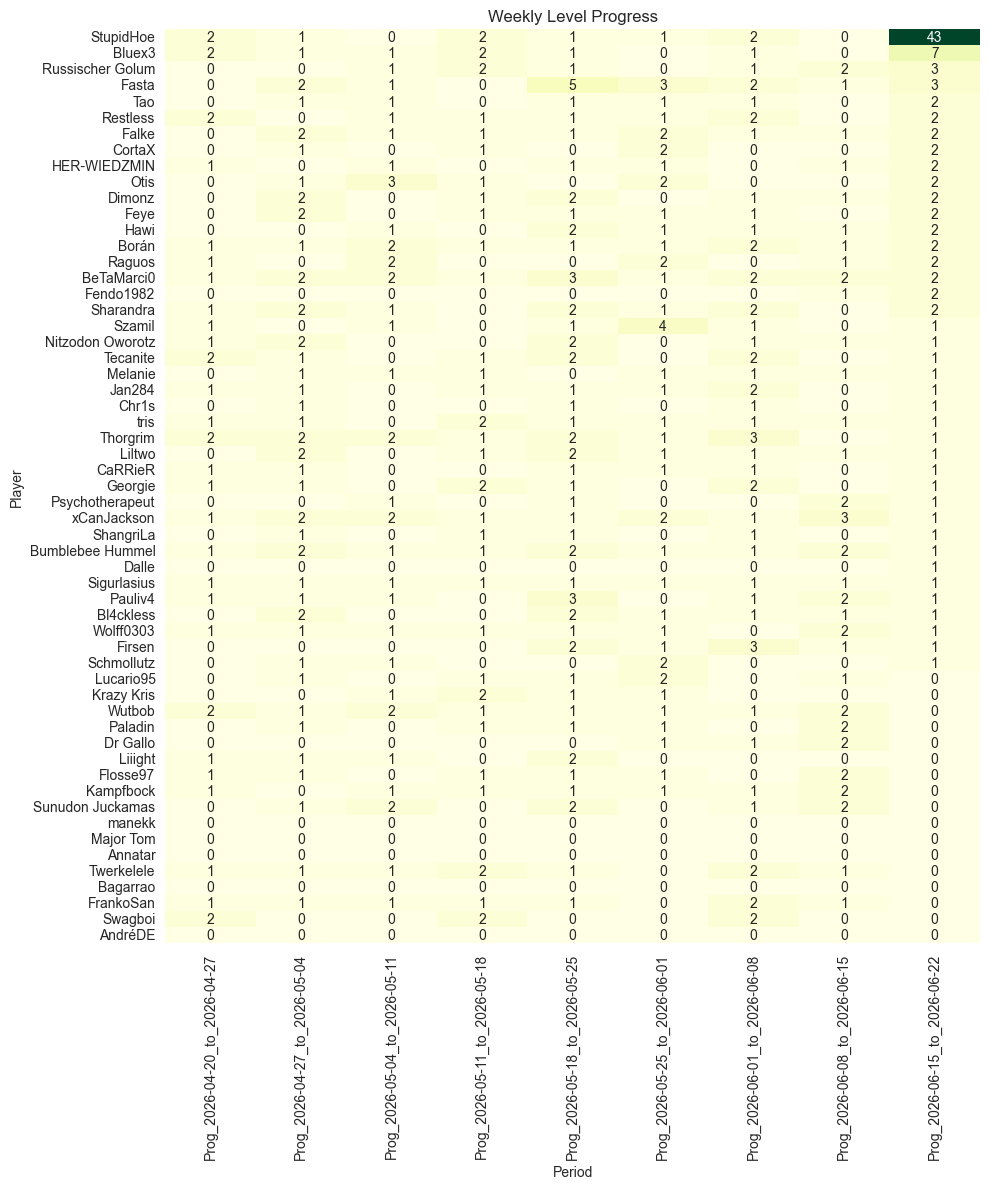

In [3]:
prog_cols = [c for c in final_df.columns if "Prog" in c]
latest_prog = prog_cols[-1]
final_df_sorted = final_df.sort_values(by=latest_prog, ascending=False)
plot_data = final_df_sorted.set_index("player_name")[prog_cols]
plt.figure(figsize=(10, 12))

plt.figure(figsize=(10, 12))
sns.heatmap(plot_data,
            annot = True,
            cmap = "YlGn",
            cbar_kws = {"label": "Level Up"},
            cbar = False)

plt.title("Weekly Level Progress")
plt.xlabel("Period")
plt.ylabel("Player")
plt.tight_layout()

# save visualization and show
save_path = "../visualizations/Q2_2026/weekly_analyses/weekly_level_progress_from_cw23_to_26_2026.png"  #change weekly
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()